# Association Rules Mining: A Comprehensive Analysis

## Overview
This notebook explores Association Rules Mining on two different datasets:
- **Retail_Transaction_Dataset.csv**: Dense dataset (4 unique item categories)
- **Assignment-1_Data.csv**: Sparse dataset (4,185 unique items)

## Association Rules Metrics
We will analyze rules using key metrics:
- **Support**: How frequently the rule appears in the dataset
- **Confidence**: How often the rule is correct
- **Lift**: How much more likely consequent is given antecedent
- **Conviction**: Measures implication strength
- **Leverage**: Difference between observed and expected frequency

# Section 1: Setup & Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import defaultdict
from typing import List, Dict, Tuple

# MLxtend for Frequent Pattern Mining and Association Rules
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
def load_and_group_transactions(filepath: str, id_col: str, item_col: str, delimiter: str = ',') -> Tuple[List[List[str]], pd.DataFrame]:
    print(f"Loading {filepath}...")
    
    try:
        df = pd.read_csv(filepath, sep=delimiter, on_bad_lines='skip', low_memory=False)
    except Exception as e:
        print(f"Failed to load CSV: {e}")
        return [], None
    
    # Clean column names
    df.columns = [c.strip() for c in df.columns]
    
    # Validate columns exist
    if id_col not in df.columns or item_col not in df.columns:
        print(f"ERROR: Column '{id_col}' or '{item_col}' not found!")
        print(f"Available columns: {list(df.columns)}")
        return [], None
    
    # Drop rows with missing values
    df = df.dropna(subset=[id_col, item_col])
    
    # Ensure item column is string
    df[item_col] = df[item_col].astype(str).str.strip()
    
    # Group by ID and create transaction lists
    print(f"Grouping items by '{id_col}'...")
    grouped = df.groupby(id_col)[item_col].apply(lambda x: list(set(x)))
    transactions = grouped.tolist()
    
    print(f"Created {len(transactions)} transactions")
    if len(transactions) > 0:
        print(f"Sample transaction: {transactions[0][:5]}..." if len(transactions[0]) > 5 else f"Sample transaction: {transactions[0]}")
    
    return transactions, df


def convert_to_onehot(transactions: List[List[str]]) -> pd.DataFrame:
    """
    Convert transactions to one-hot encoded DataFrame for mlxtend.
    """
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    return pd.DataFrame(te_array, columns=te.columns_)


def get_transaction_stats(transactions: List[List[str]], name: str) -> None:
    """
    Print statistics about transaction data.
    """
    if not transactions:
        print(f"\n[{name}] No data!")
        return
    
    lengths = [len(t) for t in transactions]
    unique_items = set(item for trans in transactions for item in trans)
    
    print(f"\n[{name}] Statistics:")
    print(f"  - Total transactions: {len(transactions):,}")
    print(f"  - Unique items: {len(unique_items):,}")
    print(f"  - Avg items per transaction: {np.mean(lengths):.2f}")
    print(f"  - Max items in a transaction: {max(lengths)}")
    print(f"  - Min items in a transaction: {min(lengths)}")

In [3]:
# Load Retail Dataset
retail_transactions, df_retail = load_and_group_transactions(
    '../datasets/Retail_Transaction_Dataset.csv',
    id_col='CustomerID',
    item_col='ProductCategory',
    delimiter=','
)
get_transaction_stats(retail_transactions, "Retail")

# Convert to one-hot format
retail_onehot = convert_to_onehot(retail_transactions)
print(f"\nOne-hot shape: {retail_onehot.shape}")
print(f"Items: {list(retail_onehot.columns)}")

Loading ../datasets/Retail_Transaction_Dataset.csv...
Grouping items by 'CustomerID'...
Created 95215 transactions
Sample transaction: ['Books']

[Retail] Statistics:
  - Total transactions: 95,215
  - Unique items: 4
  - Avg items per transaction: 1.04
  - Max items in a transaction: 3
  - Min items in a transaction: 1

One-hot shape: (95215, 4)
Items: ['Books', 'Clothing', 'Electronics', 'Home Decor']


In [4]:
# Load Assignment Dataset (semicolon-separated)
assignment_transactions, df_assignment = load_and_group_transactions(
    '../datasets/Assignment-1_Data.csv',
    id_col='BillNo',
    item_col='Itemname',
    delimiter=';'
)
get_transaction_stats(assignment_transactions, "Assignment")

# Convert to one-hot format
assignment_onehot = convert_to_onehot(assignment_transactions)
print(f"\nOne-hot shape: {assignment_onehot.shape}")

Loading ../datasets/Assignment-1_Data.csv...
Grouping items by 'BillNo'...
Created 20208 transactions
Sample transaction: ['WHITE METAL LANTERN', 'RED WOOLLY HOTTIE WHITE HEART.', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'WHITE HANGING HEART T-LIGHT HOLDER', 'SET 7 BABUSHKA NESTING BOXES']...

[Assignment] Statistics:
  - Total transactions: 20,208
  - Unique items: 4,185
  - Avg items per transaction: 25.23
  - Max items in a transaction: 1108
  - Min items in a transaction: 1

One-hot shape: (20208, 4185)


# Section 2: Association Rules Generation

Association rules are generated from frequent itemsets. The process:
1. Find frequent itemsets using Apriori or FP-Growth
2. Generate rules from itemsets that meet minimum confidence threshold

A rule has the form: **Antecedent -> Consequent** (e.g., {Bread, Butter} -> {Milk})

In [5]:
def generate_association_rules(
    df_onehot: pd.DataFrame,
    min_support: float = 0.01,
    min_confidence: float = 0.5,
    algorithm: str = 'fpgrowth'
) -> Tuple[pd.DataFrame, pd.DataFrame, float]:
    """
    Generate association rules from transaction data.
    
    Args:
        df_onehot: One-hot encoded transaction DataFrame
        min_support: Minimum support threshold for frequent itemsets
        min_confidence: Minimum confidence threshold for rules
        algorithm: 'apriori' or 'fpgrowth'
    
    Returns:
        Tuple of (frequent_itemsets, rules, execution_time)
    """
    start_time = time.perf_counter()
    
    # Step 1: Find frequent itemsets
    if algorithm == 'apriori':
        itemsets = apriori(df_onehot, min_support=min_support, use_colnames=True)
    else:
        itemsets = fpgrowth(df_onehot, min_support=min_support, use_colnames=True)
    
    # Step 2: Generate rules
    if len(itemsets) == 0:
        return itemsets, pd.DataFrame(), time.perf_counter() - start_time
    
    # Need at least 2-itemsets for rules
    if itemsets['itemsets'].apply(len).max() < 2:
        return itemsets, pd.DataFrame(), time.perf_counter() - start_time
    
    rules = association_rules(itemsets, metric='confidence', min_threshold=min_confidence)
    
    execution_time = time.perf_counter() - start_time
    return itemsets, rules, execution_time


def format_rule(row) -> str:
    """
    Format a rule row as readable string.
    """
    ant = ', '.join(sorted(row['antecedents']))
    cons = ', '.join(sorted(row['consequents']))
    return f"{{{ant}}} -> {{{cons}}}"

In [6]:
# Generate rules for Retail Dataset
print("=" * 60)
print("RETAIL DATASET: Association Rules Generation")
print("=" * 60)

retail_itemsets, retail_rules, retail_time = generate_association_rules(
    retail_onehot,
    min_support=0.01,
    min_confidence=0.3
)

print(f"\nExecution time: {retail_time:.4f} seconds")
print(f"Frequent itemsets found: {len(retail_itemsets)}")
print(f"Association rules generated: {len(retail_rules)}")

if len(retail_rules) > 0:
    print("\nSample rules (Top 5 by Lift):")
    top_rules = retail_rules.nlargest(5, 'lift').copy()
    top_rules['rule'] = top_rules.apply(format_rule, axis=1)
    print(top_rules[['rule', 'support', 'confidence', 'lift']].to_string(index=False))

RETAIL DATASET: Association Rules Generation

Execution time: 0.0910 seconds
Frequent itemsets found: 4
Association rules generated: 0


In [7]:
# Generate rules for Assignment Dataset
print("=" * 60)
print("ASSIGNMENT DATASET: Association Rules Generation")
print("=" * 60)

assignment_itemsets, assignment_rules, assignment_time = generate_association_rules(
    assignment_onehot,
    min_support=0.01,
    min_confidence=0.3
)

print(f"\nExecution time: {assignment_time:.4f} seconds")
print(f"Frequent itemsets found: {len(assignment_itemsets)}")
print(f"Association rules generated: {len(assignment_rules)}")

if len(assignment_rules) > 0:
    print("\nSample rules (Top 10 by Lift):")
    top_rules = assignment_rules.nlargest(10, 'lift').copy()
    top_rules['rule'] = top_rules.apply(format_rule, axis=1)
    for _, row in top_rules.iterrows():
        print(f"  {row['rule']}")
        print(f"    Support: {row['support']:.4f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.2f}")

ASSIGNMENT DATASET: Association Rules Generation

Execution time: 20.1534 seconds
Frequent itemsets found: 1778
Association rules generated: 1655

Sample rules (Top 10 by Lift):
  {HERB MARKER THYME} -> {HERB MARKER ROSEMARY}
    Support: 0.0107, Confidence: 0.9313, Lift: 80.43
  {HERB MARKER ROSEMARY} -> {HERB MARKER THYME}
    Support: 0.0107, Confidence: 0.9274, Lift: 80.43
  {HERB MARKER PARSLEY} -> {HERB MARKER THYME}
    Support: 0.0104, Confidence: 0.9052, Lift: 78.51
  {HERB MARKER THYME} -> {HERB MARKER PARSLEY}
    Support: 0.0104, Confidence: 0.9013, Lift: 78.51
  {HERB MARKER PARSLEY} -> {HERB MARKER ROSEMARY}
    Support: 0.0104, Confidence: 0.9052, Lift: 78.17
  {HERB MARKER ROSEMARY} -> {HERB MARKER PARSLEY}
    Support: 0.0104, Confidence: 0.8974, Lift: 78.17
  {HERB MARKER PARSLEY} -> {HERB MARKER MINT}
    Support: 0.0103, Confidence: 0.8966, Lift: 76.77
  {HERB MARKER MINT} -> {HERB MARKER PARSLEY}
    Support: 0.0103, Confidence: 0.8814, Lift: 76.77
  {HERB MARKER B

# Section 3: Association Rules Metrics Analysis

## Key Metrics Explained:

### 1. Support
- **Definition**: Fraction of transactions containing both antecedent and consequent
- **Formula**: `support(A -> B) = P(A ∪ B) = count(A ∪ B) / total_transactions`
- **Range**: [0, 1]
- **Interpretation**: Higher = rule appears more frequently

### 2. Confidence
- **Definition**: Probability of consequent given antecedent
- **Formula**: `confidence(A -> B) = P(B|A) = support(A ∪ B) / support(A)`
- **Range**: [0, 1]
- **Interpretation**: Higher = antecedent more reliably predicts consequent

### 3. Lift
- **Definition**: How much more likely B is purchased when A is purchased
- **Formula**: `lift(A -> B) = confidence(A -> B) / support(B)`
- **Range**: (0, ∞)
- **Interpretation**:
  - Lift = 1: A and B are independent
  - Lift > 1: Positive association (A increases likelihood of B)
  - Lift < 1: Negative association (A decreases likelihood of B)

### 4. Conviction
- **Definition**: Measures how much the rule is expected to fail if items were independent
- **Formula**: `conviction(A -> B) = (1 - support(B)) / (1 - confidence(A -> B))`
- **Range**: [0, ∞)
- **Interpretation**: Higher = stronger implication (∞ means perfect implication)

### 5. Leverage
- **Definition**: Difference between observed and expected frequency if independent
- **Formula**: `leverage(A -> B) = support(A ∪ B) - support(A) * support(B)`
- **Range**: [-0.25, 0.25]
- **Interpretation**: Higher positive = stronger association

In [8]:
def analyze_rules_metrics(rules: pd.DataFrame, name: str) -> None:
    """
    Analyze and display statistics for association rule metrics.
    """
    if rules.empty:
        print(f"\n[{name}] No rules to analyze.")
        return
    
    print(f"\n{'=' * 60}")
    print(f"METRICS ANALYSIS: {name}")
    print(f"{'=' * 60}")
    print(f"Total rules: {len(rules)}")
    
    metrics = ['support', 'confidence', 'lift', 'conviction', 'leverage']
    
    print(f"\n{'Metric':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 52)
    
    for metric in metrics:
        if metric in rules.columns:
            # Handle infinite values in conviction
            data = rules[metric].replace([np.inf, -np.inf], np.nan).dropna()
            if len(data) > 0:
                print(f"{metric:<12} {data.mean():>10.4f} {data.std():>10.4f} {data.min():>10.4f} {data.max():>10.4f}")
    
    # Additional insights
    print(f"\nKey Insights:")
    print(f"  - High confidence rules (>0.8): {len(rules[rules['confidence'] >= 0.8])}")
    print(f"  - High lift rules (>2.0): {len(rules[rules['lift'] >= 2.0])}")
    print(f"  - Rules with lift > 1: {len(rules[rules['lift'] > 1])} ({100*len(rules[rules['lift'] > 1])/len(rules):.1f}%)")

In [9]:
# Analyze Retail rules
analyze_rules_metrics(retail_rules, "RETAIL DATASET")


[RETAIL DATASET] No rules to analyze.


In [10]:
# Analyze Assignment rules
analyze_rules_metrics(assignment_rules, "ASSIGNMENT DATASET")


METRICS ANALYSIS: ASSIGNMENT DATASET
Total rules: 1655

Metric             Mean        Std        Min        Max
----------------------------------------------------
support          0.0137     0.0042     0.0100     0.0405
confidence       0.5152     0.1539     0.3001     0.9587
lift            14.0218    10.5481     2.8026    80.4287
conviction       2.3527     1.5626     1.2828    23.3736
leverage         0.0123     0.0036     0.0065     0.0344

Key Insights:
  - High confidence rules (>0.8): 86
  - High lift rules (>2.0): 1655
  - Rules with lift > 1: 1655 (100.0%)


# Section 4: Experiments

## Experiment A: Impact of min_confidence Threshold
How does varying the minimum confidence affect the number and quality of rules?

In [11]:
# Experiment A: Impact of min_confidence
print("=" * 60)
print("EXPERIMENT A: Impact of min_confidence Threshold")
print("=" * 60)

confidence_values = [0.3, 0.5, 0.7, 0.9]
fixed_support = 0.01

# Use Assignment dataset (more interesting patterns)
exp_a_results = []

print(f"\nDataset: Assignment | Fixed min_support: {fixed_support}")
print(f"\n{'min_confidence':>14} {'Itemsets':>10} {'Rules':>10} {'Avg Lift':>10} {'Avg Support':>12}")
print("-" * 58)

for min_conf in confidence_values:
    itemsets, rules, exec_time = generate_association_rules(
        assignment_onehot,
        min_support=fixed_support,
        min_confidence=min_conf
    )
    
    avg_lift = rules['lift'].mean() if len(rules) > 0 else 0
    avg_support = rules['support'].mean() if len(rules) > 0 else 0
    
    exp_a_results.append({
        'min_confidence': min_conf,
        'num_itemsets': len(itemsets),
        'num_rules': len(rules),
        'avg_lift': avg_lift,
        'avg_support': avg_support
    })
    
    print(f"{min_conf:>14.1f} {len(itemsets):>10} {len(rules):>10} {avg_lift:>10.2f} {avg_support:>12.4f}")

exp_a_df = pd.DataFrame(exp_a_results)

EXPERIMENT A: Impact of min_confidence Threshold

Dataset: Assignment | Fixed min_support: 0.01

min_confidence   Itemsets      Rules   Avg Lift  Avg Support
----------------------------------------------------------
           0.3       1778       1655      14.02       0.0137
           0.5       1778        798      17.38       0.0135
           0.7       1778        241      22.73       0.0128
           0.9       1778         15      46.89       0.0122


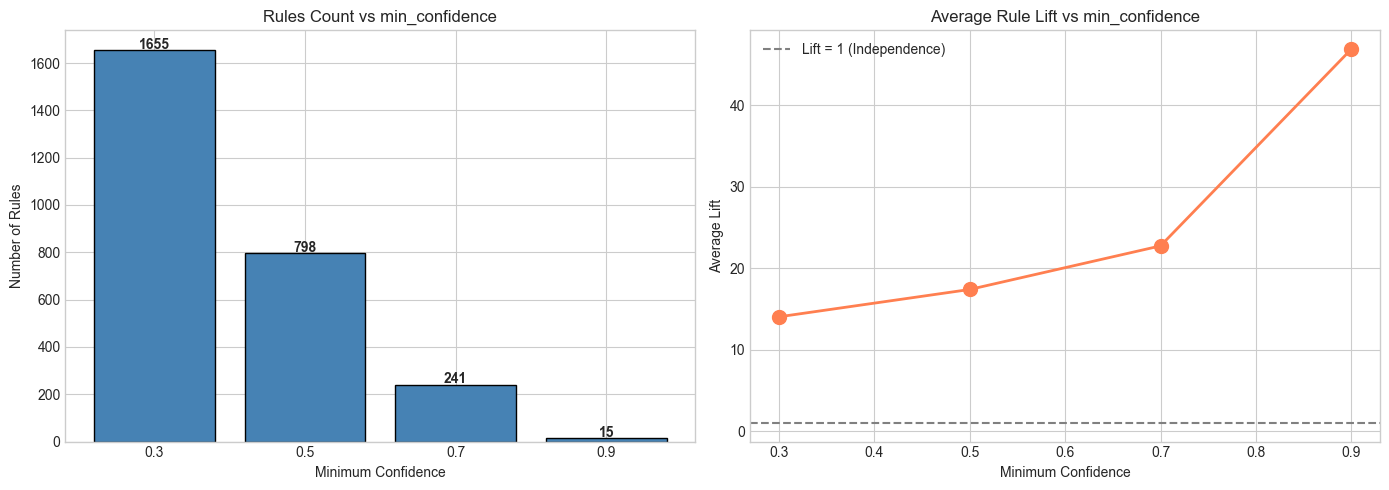


Observation: Higher confidence threshold -> Fewer but potentially higher quality rules


In [12]:
# Visualize Experiment A results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Number of rules vs confidence
ax1 = axes[0]
ax1.bar(exp_a_df['min_confidence'].astype(str), exp_a_df['num_rules'], color='steelblue', edgecolor='black')
ax1.set_xlabel('Minimum Confidence')
ax1.set_ylabel('Number of Rules')
ax1.set_title('Rules Count vs min_confidence')
for i, v in enumerate(exp_a_df['num_rules']):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Average lift vs confidence
ax2 = axes[1]
ax2.plot(exp_a_df['min_confidence'], exp_a_df['avg_lift'], marker='o', linewidth=2, markersize=10, color='coral')
ax2.set_xlabel('Minimum Confidence')
ax2.set_ylabel('Average Lift')
ax2.set_title('Average Rule Lift vs min_confidence')
ax2.axhline(y=1, color='gray', linestyle='--', label='Lift = 1 (Independence)')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nObservation: Higher confidence threshold -> Fewer but potentially higher quality rules")

## Experiment B: Impact of min_support Threshold
How does varying the minimum support affect rule generation?

In [13]:
# Experiment B: Impact of min_support
print("=" * 60)
print("EXPERIMENT B: Impact of min_support Threshold")
print("=" * 60)

support_values = [0.01, 0.02, 0.05, 0.1]
fixed_confidence = 0.5

exp_b_results = []

print(f"\nDataset: Assignment | Fixed min_confidence: {fixed_confidence}")
print(f"\n{'min_support':>12} {'Itemsets':>10} {'Rules':>10} {'Time (s)':>10} {'Avg Lift':>10}")
print("-" * 54)

for min_sup in support_values:
    itemsets, rules, exec_time = generate_association_rules(
        assignment_onehot,
        min_support=min_sup,
        min_confidence=fixed_confidence
    )
    
    avg_lift = rules['lift'].mean() if len(rules) > 0 else 0
    
    exp_b_results.append({
        'min_support': min_sup,
        'num_itemsets': len(itemsets),
        'num_rules': len(rules),
        'exec_time': exec_time,
        'avg_lift': avg_lift
    })
    
    print(f"{min_sup:>12.2f} {len(itemsets):>10} {len(rules):>10} {exec_time:>10.3f} {avg_lift:>10.2f}")

exp_b_df = pd.DataFrame(exp_b_results)

EXPERIMENT B: Impact of min_support Threshold

Dataset: Assignment | Fixed min_confidence: 0.5

 min_support   Itemsets      Rules   Time (s)   Avg Lift
------------------------------------------------------
        0.01       1778        798     19.404      17.38
        0.02        358         56      3.469      11.18
        0.05         31          0      0.862       0.00
        0.10          2          0      0.694       0.00


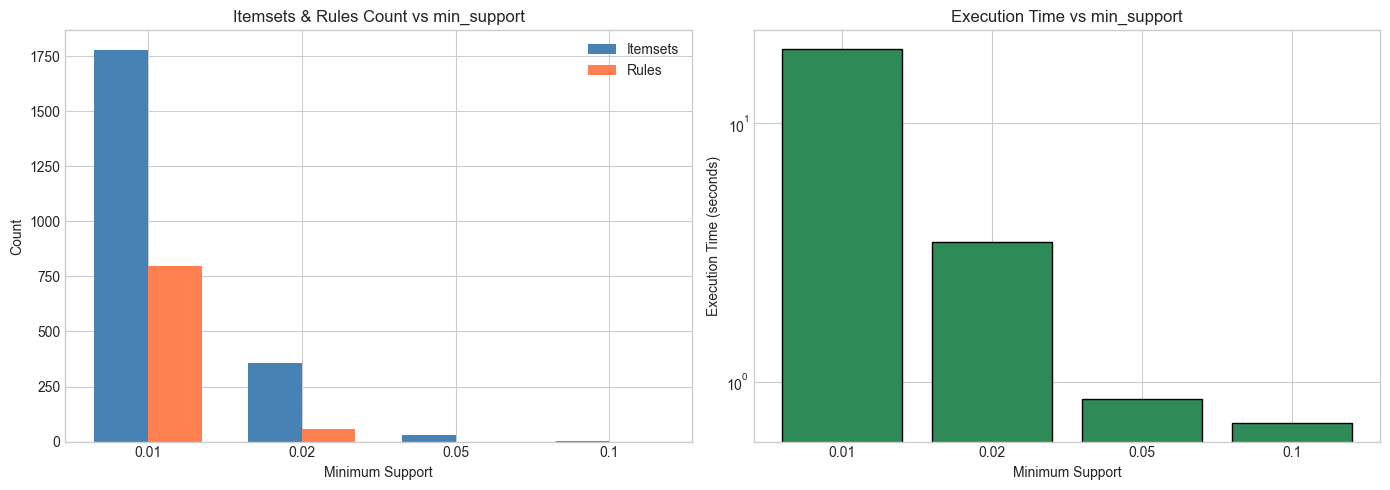


Observation: Lower support -> More itemsets/rules but longer execution time


In [14]:
# Visualize Experiment B results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Itemsets and Rules vs Support (Dual axis)
ax1 = axes[0]
x_pos = range(len(support_values))
width = 0.35

bars1 = ax1.bar([x - width/2 for x in x_pos], exp_b_df['num_itemsets'], width, label='Itemsets', color='steelblue')
bars2 = ax1.bar([x + width/2 for x in x_pos], exp_b_df['num_rules'], width, label='Rules', color='coral')

ax1.set_xlabel('Minimum Support')
ax1.set_ylabel('Count')
ax1.set_title('Itemsets & Rules Count vs min_support')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([str(s) for s in support_values])
ax1.legend()

# Plot 2: Execution Time
ax2 = axes[1]
ax2.bar(exp_b_df['min_support'].astype(str), exp_b_df['exec_time'], color='seagreen', edgecolor='black')
ax2.set_xlabel('Minimum Support')
ax2.set_ylabel('Execution Time (seconds)')
ax2.set_title('Execution Time vs min_support')
ax2.set_yscale('log')  # Log scale for better visualization

plt.tight_layout()
plt.show()

print("\nObservation: Lower support -> More itemsets/rules but longer execution time")

## Experiment C: Dataset Comparison
Compare rule characteristics between dense (Retail) and sparse (Assignment) datasets.

In [15]:
# Experiment C: Dataset Comparison
print("=" * 60)
print("EXPERIMENT C: Dataset Comparison (Dense vs Sparse)")
print("=" * 60)

# Use same parameters for fair comparison
comparison_support = 0.01
comparison_confidence = 0.3

# Generate rules for both datasets
retail_is, retail_r, retail_t = generate_association_rules(
    retail_onehot, min_support=comparison_support, min_confidence=comparison_confidence
)

assign_is, assign_r, assign_t = generate_association_rules(
    assignment_onehot, min_support=comparison_support, min_confidence=comparison_confidence
)

print(f"\nParameters: min_support={comparison_support}, min_confidence={comparison_confidence}")
print(f"\n{'Metric':<25} {'Retail (Dense)':<20} {'Assignment (Sparse)':<20}")
print("-" * 65)
print(f"{'Unique Items':<25} {retail_onehot.shape[1]:<20} {assignment_onehot.shape[1]:<20}")
print(f"{'Transactions':<25} {len(retail_transactions):<20,} {len(assignment_transactions):<20,}")
print(f"{'Frequent Itemsets':<25} {len(retail_is):<20} {len(assign_is):<20}")
print(f"{'Association Rules':<25} {len(retail_r):<20} {len(assign_r):<20}")
print(f"{'Execution Time (s)':<25} {retail_t:<20.4f} {assign_t:<20.4f}")

if len(retail_r) > 0 and len(assign_r) > 0:
    print(f"{'Avg Confidence':<25} {retail_r['confidence'].mean():<20.4f} {assign_r['confidence'].mean():<20.4f}")
    print(f"{'Avg Lift':<25} {retail_r['lift'].mean():<20.4f} {assign_r['lift'].mean():<20.4f}")
    print(f"{'Max Lift':<25} {retail_r['lift'].max():<20.4f} {assign_r['lift'].max():<20.4f}")

EXPERIMENT C: Dataset Comparison (Dense vs Sparse)

Parameters: min_support=0.01, min_confidence=0.3

Metric                    Retail (Dense)       Assignment (Sparse) 
-----------------------------------------------------------------
Unique Items              4                    4185                
Transactions              95,215               20,208              
Frequent Itemsets         4                    1778                
Association Rules         0                    1655                
Execution Time (s)        0.1028               19.8567             


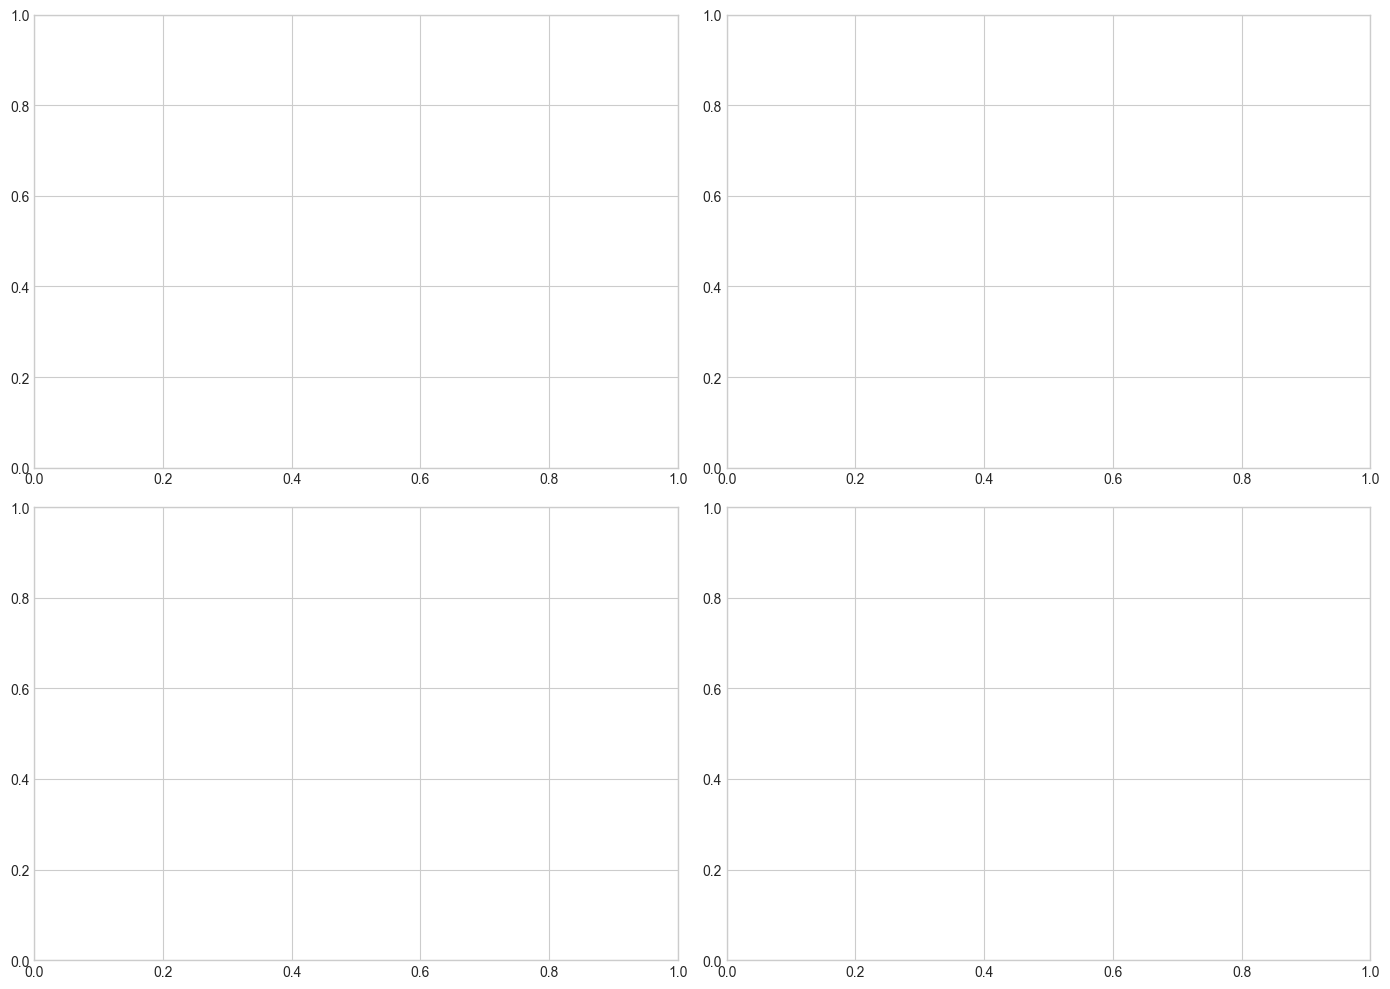

In [24]:
# Visualize distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Only plot if we have rules
if len(retail_r) > 0 and len(assign_r) > 0:
    # Confidence distribution
    axes[0, 0].hist(retail_r['confidence'], bins=20, alpha=0.6, label='Retail', color='steelblue', edgecolor='black')
    axes[0, 0].hist(assign_r['confidence'], bins=20, alpha=0.6, label='Assignment', color='coral', edgecolor='black')
    axes[0, 0].set_xlabel('Confidence')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Confidence Distribution')
    axes[0, 0].legend()
    
    # Lift distribution
    axes[0, 1].hist(retail_r['lift'], bins=20, alpha=0.6, label='Retail', color='steelblue', edgecolor='black')
    axes[0, 1].hist(assign_r['lift'], bins=20, alpha=0.6, label='Assignment', color='coral', edgecolor='black')
    axes[0, 1].set_xlabel('Lift')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Lift Distribution')
    axes[0, 1].axvline(x=1, color='gray', linestyle='--', label='Lift = 1')
    axes[0, 1].legend()
    
    # Support distribution
    axes[1, 0].hist(retail_r['support'], bins=20, alpha=0.6, label='Retail', color='steelblue', edgecolor='black')
    axes[1, 0].hist(assign_r['support'], bins=20, alpha=0.6, label='Assignment', color='coral', edgecolor='black')
    axes[1, 0].set_xlabel('Support')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Support Distribution')
    axes[1, 0].legend()
    
    # Leverage distribution
    axes[1, 1].hist(retail_r['leverage'], bins=20, alpha=0.6, label='Retail', color='steelblue', edgecolor='black')
    axes[1, 1].hist(assign_r['leverage'], bins=20, alpha=0.6, label='Assignment', color='coral', edgecolor='black')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Leverage Distribution')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Section 5: Visualizations

Advanced visualizations for understanding association rules.

In [17]:
# Use Assignment dataset for visualizations (more interesting patterns)
rules_to_viz = assign_r if len(assign_r) > 0 else retail_r
dataset_name = "Assignment" if len(assign_r) > 0 else "Retail"

print(f"Visualizing rules from {dataset_name} dataset ({len(rules_to_viz)} rules)")

Visualizing rules from Assignment dataset (1655 rules)


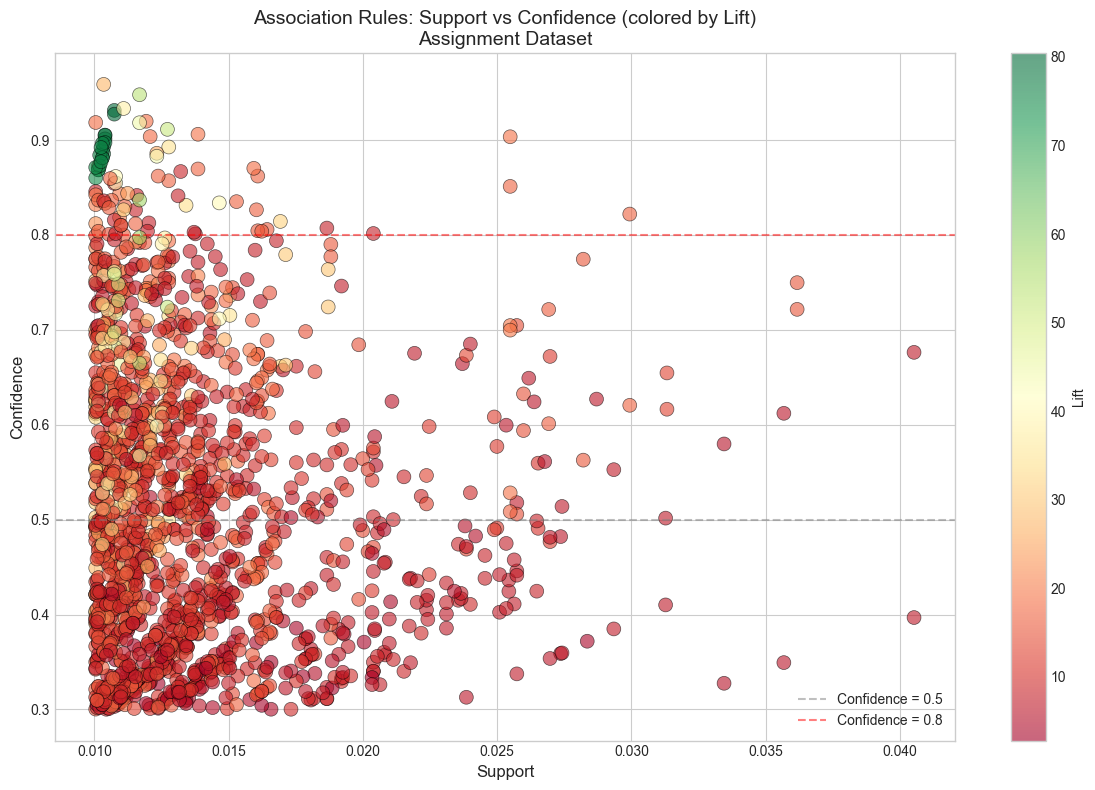

In [18]:
# Visualization 1: Support vs Confidence scatter plot (colored by Lift)
if len(rules_to_viz) > 0:
    plt.figure(figsize=(12, 8))
    
    scatter = plt.scatter(
        rules_to_viz['support'],
        rules_to_viz['confidence'],
        c=rules_to_viz['lift'],
        cmap='RdYlGn',
        s=100,
        alpha=0.6,
        edgecolors='black',
        linewidths=0.5
    )
    
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title(f'Association Rules: Support vs Confidence (colored by Lift)\n{dataset_name} Dataset', fontsize=14)
    
    # Add reference lines
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Confidence = 0.5')
    plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Confidence = 0.8')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No rules to visualize.")

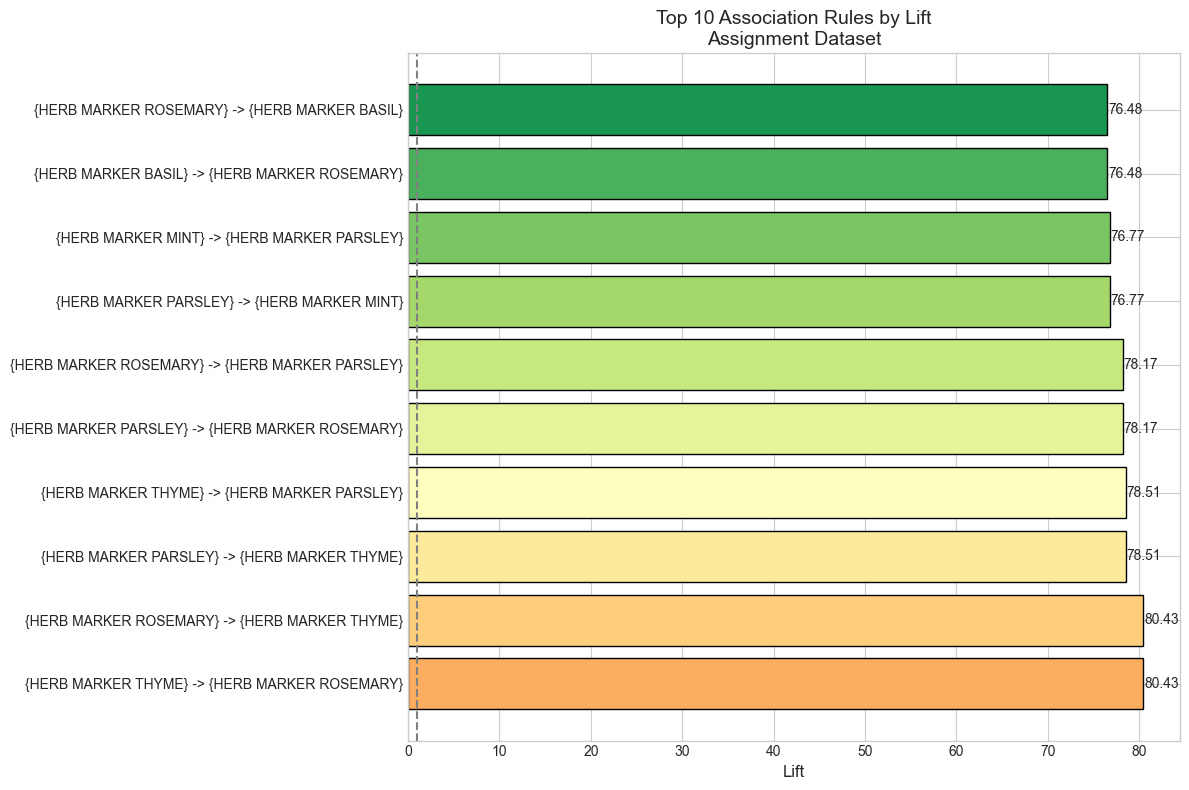


Top 10 Rules Details:

1. {HERB MARKER THYME} -> {HERB MARKER ROSEMARY}
   Support: 0.0107, Confidence: 0.9313, Lift: 80.43

2. {HERB MARKER ROSEMARY} -> {HERB MARKER THYME}
   Support: 0.0107, Confidence: 0.9274, Lift: 80.43

3. {HERB MARKER PARSLEY} -> {HERB MARKER THYME}
   Support: 0.0104, Confidence: 0.9052, Lift: 78.51

4. {HERB MARKER THYME} -> {HERB MARKER PARSLEY}
   Support: 0.0104, Confidence: 0.9013, Lift: 78.51

5. {HERB MARKER PARSLEY} -> {HERB MARKER ROSEMARY}
   Support: 0.0104, Confidence: 0.9052, Lift: 78.17

6. {HERB MARKER ROSEMARY} -> {HERB MARKER PARSLEY}
   Support: 0.0104, Confidence: 0.8974, Lift: 78.17

7. {HERB MARKER PARSLEY} -> {HERB MARKER MINT}
   Support: 0.0103, Confidence: 0.8966, Lift: 76.77

8. {HERB MARKER MINT} -> {HERB MARKER PARSLEY}
   Support: 0.0103, Confidence: 0.8814, Lift: 76.77

9. {HERB MARKER BASIL} -> {HERB MARKER ROSEMARY}
   Support: 0.0103, Confidence: 0.8856, Lift: 76.48

10. {HERB MARKER ROSEMARY} -> {HERB MARKER BASIL}
   Support

In [19]:
# Visualization 2: Top 10 Rules by Lift (Bar Chart)
if len(rules_to_viz) > 0:
    top_n = min(10, len(rules_to_viz))
    top_rules = rules_to_viz.nlargest(top_n, 'lift').copy()
    top_rules['rule'] = top_rules.apply(format_rule, axis=1)
    
    # Truncate long rule names
    top_rules['rule_short'] = top_rules['rule'].apply(lambda x: x[:50] + '...' if len(x) > 50 else x)
    
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
    bars = plt.barh(range(top_n), top_rules['lift'].values, color=colors, edgecolor='black')
    
    plt.yticks(range(top_n), top_rules['rule_short'].values)
    plt.xlabel('Lift', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Lift\n{dataset_name} Dataset', fontsize=14)
    plt.axvline(x=1, color='gray', linestyle='--', label='Lift = 1')
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{top_rules["lift"].iloc[i]:.2f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print full rule details
    print(f"\nTop {top_n} Rules Details:")
    for i, (_, row) in enumerate(top_rules.iterrows(), 1):
        print(f"\n{i}. {row['rule']}")
        print(f"   Support: {row['support']:.4f}, Confidence: {row['confidence']:.4f}, Lift: {row['lift']:.2f}")

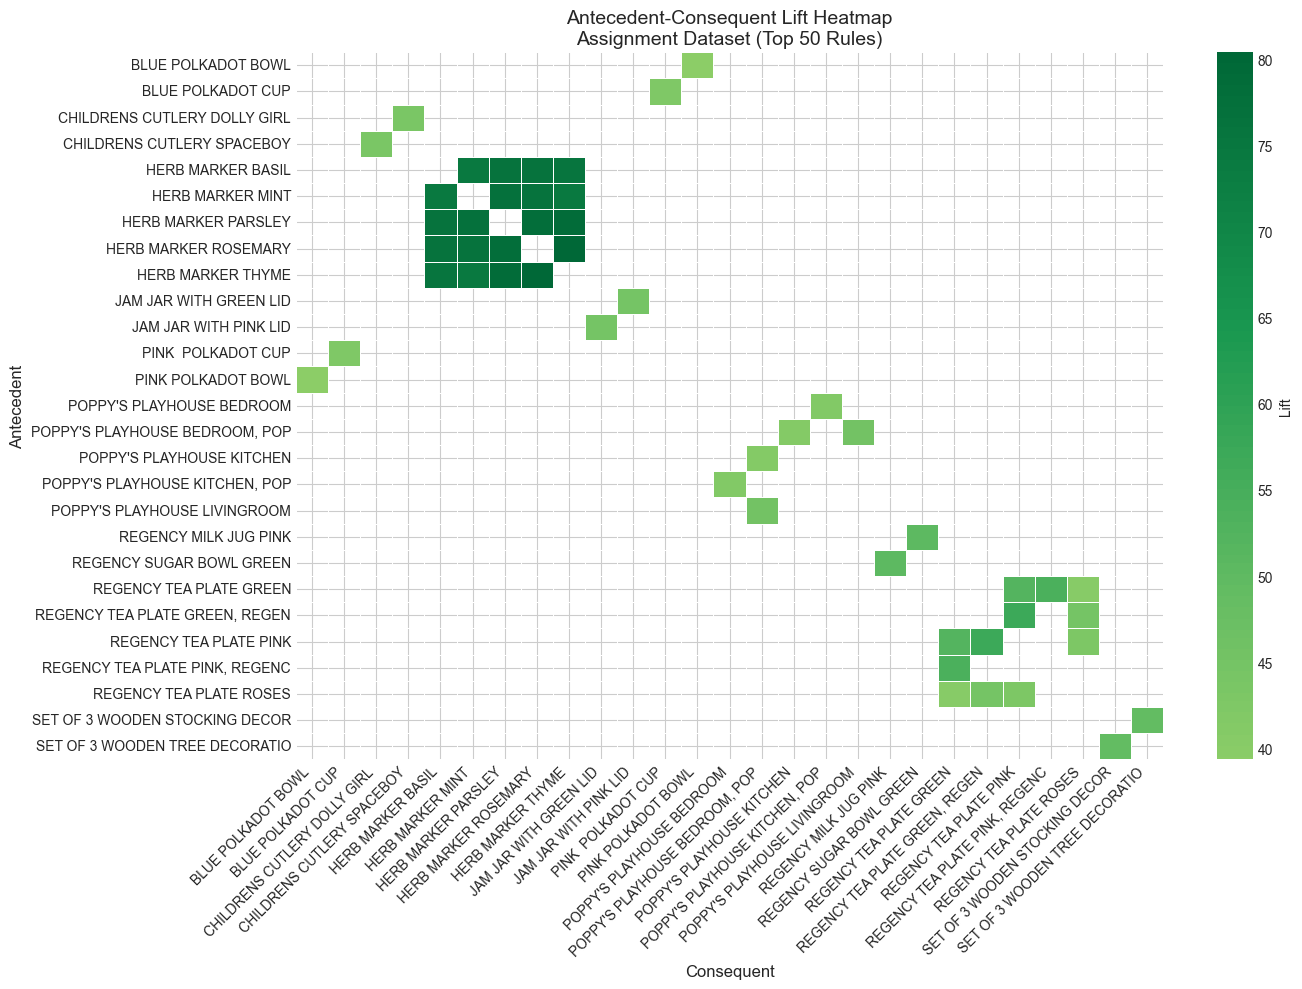

In [20]:
# Visualization 3: Heatmap of Antecedent-Consequent relationships
if len(rules_to_viz) > 0:
    # Get unique items from top rules
    top_rules_for_heatmap = rules_to_viz.nlargest(50, 'lift').copy()
    
    # Create simple antecedent/consequent strings
    top_rules_for_heatmap['ant_str'] = top_rules_for_heatmap['antecedents'].apply(lambda x: ', '.join(sorted(x))[:30])
    top_rules_for_heatmap['cons_str'] = top_rules_for_heatmap['consequents'].apply(lambda x: ', '.join(sorted(x))[:30])
    
    # Create pivot for heatmap
    pivot = top_rules_for_heatmap.pivot_table(
        index='ant_str', 
        columns='cons_str', 
        values='lift',
        aggfunc='mean'
    )
    
    # Only show if we have a reasonable sized matrix
    if pivot.shape[0] > 1 and pivot.shape[1] > 1:
        plt.figure(figsize=(14, 10))
        sns.heatmap(
            pivot, 
            cmap='RdYlGn', 
            center=1,
            annot=True if pivot.size < 100 else False,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Lift'}
        )
        plt.title(f'Antecedent-Consequent Lift Heatmap\n{dataset_name} Dataset (Top 50 Rules)', fontsize=14)
        plt.xlabel('Consequent', fontsize=12)
        plt.ylabel('Antecedent', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough distinct antecedent-consequent pairs for heatmap.")

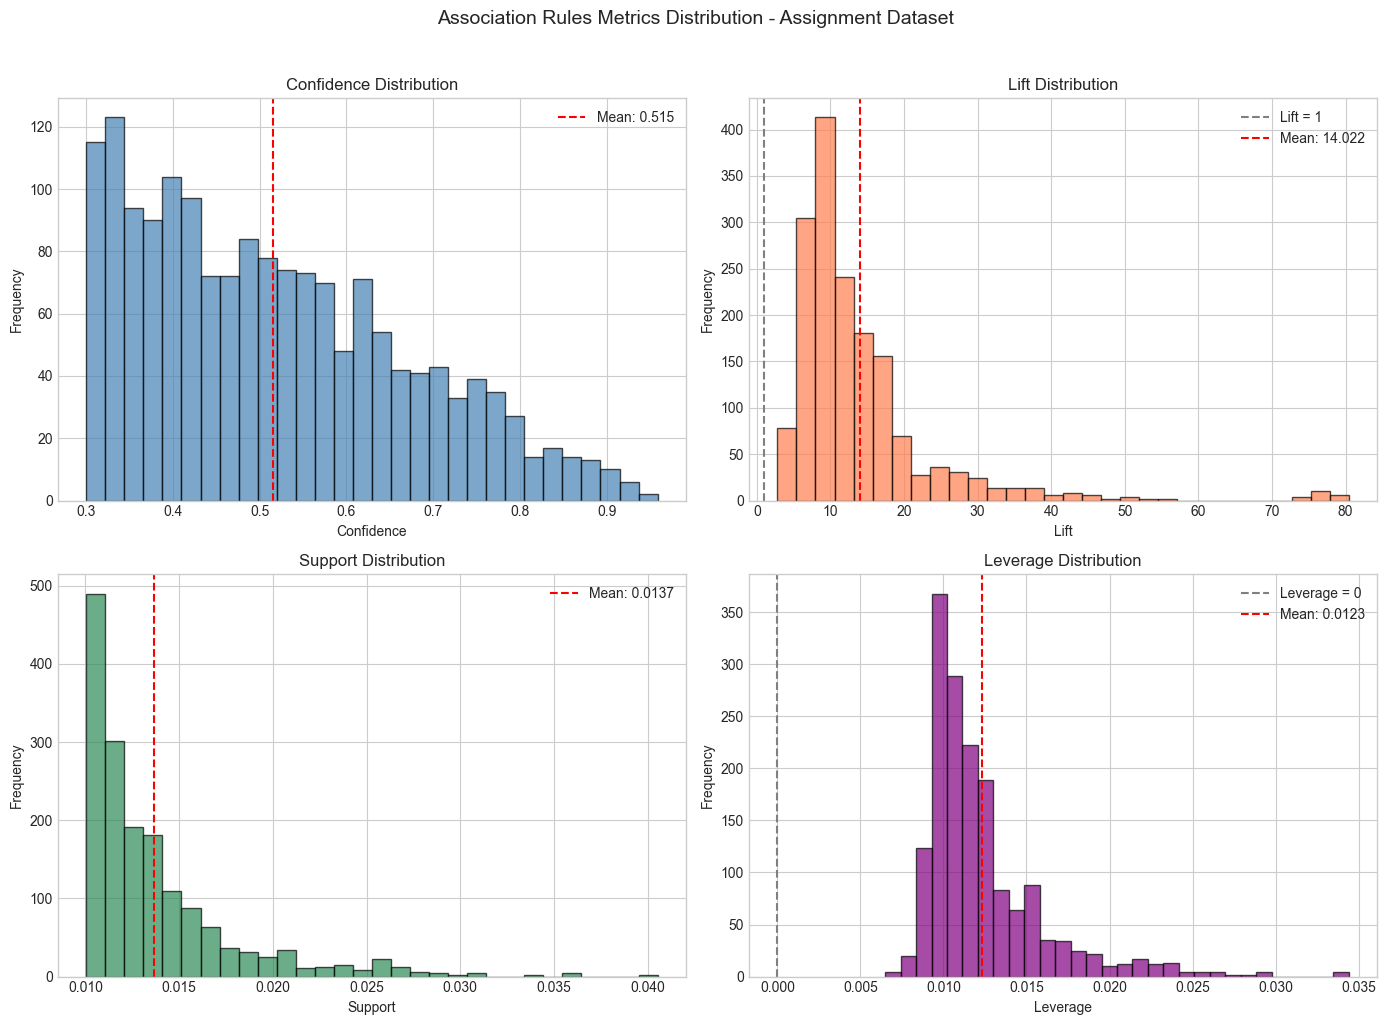

In [21]:
# Visualization 4: Metrics Distribution Histograms
if len(rules_to_viz) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Confidence distribution
    axes[0, 0].hist(rules_to_viz['confidence'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(rules_to_viz['confidence'].mean(), color='red', linestyle='--', label=f"Mean: {rules_to_viz['confidence'].mean():.3f}")
    axes[0, 0].set_xlabel('Confidence')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Confidence Distribution')
    axes[0, 0].legend()
    
    # Lift distribution
    axes[0, 1].hist(rules_to_viz['lift'], bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(1, color='gray', linestyle='--', label='Lift = 1')
    axes[0, 1].axvline(rules_to_viz['lift'].mean(), color='red', linestyle='--', label=f"Mean: {rules_to_viz['lift'].mean():.3f}")
    axes[0, 1].set_xlabel('Lift')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Lift Distribution')
    axes[0, 1].legend()
    
    # Support distribution
    axes[1, 0].hist(rules_to_viz['support'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(rules_to_viz['support'].mean(), color='red', linestyle='--', label=f"Mean: {rules_to_viz['support'].mean():.4f}")
    axes[1, 0].set_xlabel('Support')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Support Distribution')
    axes[1, 0].legend()
    
    # Leverage distribution
    axes[1, 1].hist(rules_to_viz['leverage'], bins=30, color='purple', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(0, color='gray', linestyle='--', label='Leverage = 0')
    axes[1, 1].axvline(rules_to_viz['leverage'].mean(), color='red', linestyle='--', label=f"Mean: {rules_to_viz['leverage'].mean():.4f}")
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Leverage Distribution')
    axes[1, 1].legend()
    
    plt.suptitle(f'Association Rules Metrics Distribution - {dataset_name} Dataset', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Section 6: Summary & Insights

In [23]:
# Final display of best rules
print("\n" + "=" * 70)
print("TOP 5 MOST ACTIONABLE RULES (High Lift + High Confidence)")
print("=" * 70)

if len(assign_r) > 0:
    # Filter for actionable rules
    actionable = assign_r[(assign_r['lift'] > 2) & (assign_r['confidence'] > 0.5)]
    
    if len(actionable) > 0:
        top_actionable = actionable.nlargest(5, 'lift')
        
        for i, (_, row) in enumerate(top_actionable.iterrows(), 1):
            ant = ', '.join(sorted(row['antecedents']))
            cons = ', '.join(sorted(row['consequents']))
            print(f"\n{i}. IF customer buys: {ant}")
            print(f"   THEN recommend: {cons}")
            print(f"   Support: {row['support']:.4f} | Confidence: {row['confidence']:.2%} | Lift: {row['lift']:.2f}")
    else:
        print("No rules meeting the actionable criteria (lift > 2, confidence > 0.5).")
else:
    print("No rules available for Assignment dataset.")


TOP 5 MOST ACTIONABLE RULES (High Lift + High Confidence)

1. IF customer buys: HERB MARKER THYME
   THEN recommend: HERB MARKER ROSEMARY
   Support: 0.0107 | Confidence: 93.13% | Lift: 80.43

2. IF customer buys: HERB MARKER ROSEMARY
   THEN recommend: HERB MARKER THYME
   Support: 0.0107 | Confidence: 92.74% | Lift: 80.43

3. IF customer buys: HERB MARKER PARSLEY
   THEN recommend: HERB MARKER THYME
   Support: 0.0104 | Confidence: 90.52% | Lift: 78.51

4. IF customer buys: HERB MARKER THYME
   THEN recommend: HERB MARKER PARSLEY
   Support: 0.0104 | Confidence: 90.13% | Lift: 78.51

5. IF customer buys: HERB MARKER PARSLEY
   THEN recommend: HERB MARKER ROSEMARY
   Support: 0.0104 | Confidence: 90.52% | Lift: 78.17
